In [8]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("papluca/language-identification")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})


In [9]:
traindf = pd.DataFrame(dataset['train'])
valdf = pd.DataFrame(dataset['validation'])
testdf = pd.DataFrame(dataset['test'])

traindf.head(10)

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .
5,pl,"S Jak sobie życzysz: Widzisz, jak Hitler zabij..."
6,ur,اس کے بارے میں ، سفید شادی کی شرح کے بعد سفید ...
7,sw,Zabuni ya ushindani pia imekuwa rahisi kwa sif...
8,tr,Devasa 12 yüzyıl abbatiale saint-Pierre-Et-Sai...
9,ur,موجودہ اثاثوں میں سے ایک کا اضافہ ہو سکتا ہے ۔


In [10]:
traindf['labels'].unique()

<ArrowStringArray>
['pt', 'bg', 'zh', 'th', 'ru', 'pl', 'ur', 'sw', 'tr', 'es', 'ar', 'it', 'hi',
 'de', 'el', 'nl', 'fr', 'vi', 'en', 'ja']
Length: 20, dtype: str

In [12]:
traindf['textlen'] = traindf['text'].apply(len)
print(traindf['textlen'].mean())
print(traindf['textlen'].max())
print(traindf['textlen'].min())

110.86141428571429
2422
2


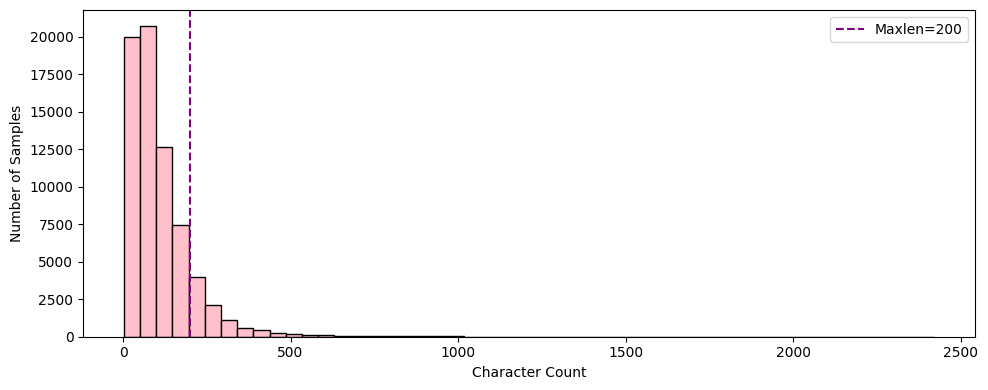

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(traindf['textlen'],bins=50,color='pink',edgecolor='black')
plt.axvline(x=200, color='purple', linestyle='--', label='Maxlen=200')
plt.xlabel('Character Count')
plt.ylabel('Number of Samples')
plt.legend()
plt.tight_layout()
plt.show()

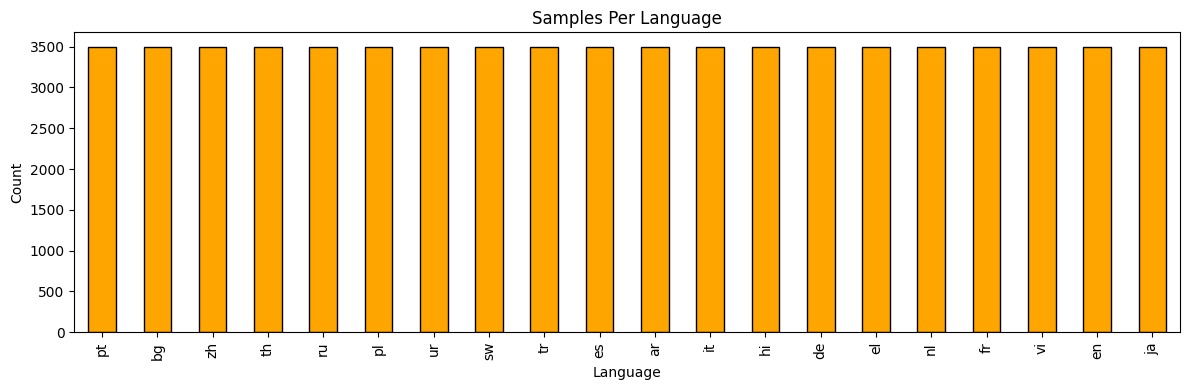

In [17]:
cnt = traindf['labels'].value_counts()

plt.figure(figsize=(12,4))
cnt.plot(kind='bar',color='orange',edgecolor='black')
plt.title('Samples Per Language')
plt.xlabel('Language')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [19]:
import os
os.makedirs('notebooks/plots', exist_ok=True)

In [20]:
plt.savefig('notebooks/plots/text_length_dist.png')
plt.savefig('notebooks/plots/language_dist.png')

<Figure size 640x480 with 0 Axes>